# XGBoost Model for Gravimetric Capacitance from the H₂SO₄ MXene Corpus

## Goal

Build a reproducible, paper-leakage-safe XGBoost regression workflow for predicting **gravimetric capacitance (F g⁻¹)** from electrode descriptors and electrochemical test conditions in `h2so4_corpus_final.csv`.

The notebook:

1. loads and audits the literature dataset;
2. normalizes mixed descriptor units;
3. rejects non-exact target values such as “over 200” rather than treating them as exact labels;
4. engineers compact, interpretable descriptor categories;
5. separates CV-conditioned and GCD-conditioned observations;
6. splits and cross-validates **by paper/DOI**, not by row;
7. compares XGBoost against a median baseline;
8. tunes XGBoost on the training papers only;
9. reports MAE, RMSE, and R² on unseen papers;
10. creates parity plots and SHAP explanations;
11. exports cleaned modeling tables and predictions.

> **Primary model:** capacitance measured at a known CV scan rate, because this subset is substantially larger.  
> **Secondary model:** capacitance measured at a known gravimetric GCD current density; treat this result as exploratory because the sample size is small.

## Key assumptions

- The prediction target is **gravimetric capacitance in F g⁻¹** only.
- Values reported only as bounds (for example, “over 200” or “exceeding 100”) are excluded from regression targets.
- Descriptor ranges such as `5–20 nm` are represented by their midpoint.
- Scan-rate ranges such as `5–100 mV s⁻¹` are **not** converted to a midpoint because they describe a test window rather than necessarily the rate associated with the reported capacitance.
- Current density is used only when explicitly reported in **A g⁻¹**.
- Missing physical descriptors are median-imputed **inside the training pipeline**, with missingness indicators retained.
- `doi`/paper identity is never used as a predictive feature; it is used only for grouped splitting and grouped cross-validation.
- Highly free-text synthesis descriptions are excluded from the first model because the corpus is too small for a defensible high-dimensional text representation.

## 1. Setup

In [1]:
%pip install -q scikit-learn xgboost shap pandas numpy matplotlib scipy

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Uncomment in a fresh Google Colab environment if needed:
# %pip install -q xgboost shap scikit-learn pandas numpy matplotlib scipy

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    RandomizedSearchCV,
    cross_validate,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

from xgboost import XGBRegressor
import shap

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_SEARCH_ITER = 20

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

import sklearn, xgboost
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("shap:", shap.__version__)

pandas: 1.4.4
scikit-learn: 1.0.2
xgboost: 2.1.4
shap: 0.49.1


## 2. Load the corpus

In [2]:
candidate_paths = [
    Path("h2so4_corpus_final.csv"),
    Path("terra/h2so4_corpus_final.csv"),
]
DATA_PATH = next((p for p in candidate_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find h2so4_corpus_final.csv. "
        "Place it in the same folder as this notebook or edit DATA_PATH."
    )

raw = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {raw.shape[0]} rows × {raw.shape[1]} columns")
print(f"Unique DOI values: {raw['doi'].nunique(dropna=True)}")
display(raw.head(3))

Loaded: terra\h2so4_corpus_final.csv
Shape: 192 rows × 83 columns
Unique DOI values: 48


,source_file,source_path,doi,year,authors,electrode_label,role,is_primary,mxene_formula,mxene_formula__unit,mxene_formula__conf,composition,composition__unit,composition__conf,synthesis_method,synthesis_method__unit,synthesis_method__conf,layer_no,layer_no__unit,layer_no__conf,layer_no__src,interlayer_spacing,interlayer_spacing__unit,interlayer_spacing__conf,interlayer_spacing__src,flake_size,flake_size__unit,flake_size__conf,flake_size__src,porosity,porosity__unit,porosity__conf,porosity__src,pore_diameter,pore_diameter__unit,pore_diameter__conf,pore_diameter__src,tortuosity,tortuosity__unit,tortuosity__conf,electrode_thickness,electrode_thickness__unit,electrode_thickness__conf,electrode_thickness__src,mass_loading,mass_loading__unit,mass_loading__conf,mass_loading__src,electrolyte,electrolyte__unit,electrolyte__conf,ssa,ssa__unit,ssa__conf,ssa__src,scan_rate,scan_rate__unit,scan_rate__conf,scan_rate__src,current_density,current_density__unit,current_density__conf,current_density__src,gravimetric_capacitance,gravimetric_capacitance__unit,gravimetric_capacitance__conf,gravimetric_capacitance__src,volumetric_capacitance,volumetric_capacitance__unit,volumetric_capacitance__conf,volumetric_capacitance__src,areal_capacitance,areal_capacitance__unit,areal_capacitance__conf,areal_capacitance__src,formula_match,formula_reasoning,synthesis_match,synthesis_reasoning,electrolyte_match,electrolyte_reasoning,overall,overall_reasoning
0,1-s2.0-S0008622325000375-main.pdf,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,2025.0,Hailong Shen et al.,NS-Ti3C2Tx-P,primary,True,Ti3C2Tx,NaN,stated,"N/S co-doped Ti3C2Tx (Ti, C, O, F, N, S)",NaN,stated,LiF/HCl etching; photothermal-assisted thiourea N/S co-doping under high-pressure mercury lamp,NaN,stated,few-layer,NaN,derived,NaN,1.42,nm,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,7.00,μm,derived,[UNVERIFIED] Back-calculated from the paper's own numbers: C_v = C_g x density and density = mass_loading / thicknes...,1.69,mg cm−2,stated,NaN,2 M H2SO4,NaN,derived,NaN,NaN,stated,NaN,2,mV s−1,stated,NaN,NaN,NaN,stated,NaN,424,F g−1,stated,NaN,1023,F cm−3,stated,NaN,0.717,F cm−2,derived,"[UNVERIFIED] C_areal = C_g x mass loading = 424 F g-1 x 1.69e-3 g cm-2 = 0.7166 F cm-2, at the stated 2 mV s-1. Cros...",True,Primary formula 'Ti3C2Tx' contains Ti3C2 (Ti3C2Tx or Ti3C2).,True,Synthesis explicitly mentions both LiF and HCl.,True,Electrolyte explicitly mentions H2SO4 (sulfuric acid).,PASS,Passes all criteria.
1,1-s2.0-S0008622325000375-main.pdf,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,2025.0,Hailong Shen et al.,NS-Ti3C2Tx-A,variant,False,Ti3C2Tx,NaN,stated,N/S co-doped Ti3C2Tx,NaN,stated,LiF/HCl etching; thiourea N/S co-doping by annealing at 300 °C for 3 h in Ar,NaN,stated,few-layer,NaN,derived,NaN,2.74,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,8.00,μm,derived,[UNVERIFIED] Same chain as NS-Ti3C2Tx-P. Stated: mass load 2.12 mg cm-2; 'the mass capacitance of NS-Ti3C2Tx-A and T...,2.12,mg cm−2,stated,NaN,2 M H2SO4,NaN,derived,NaN,NaN,stated,NaN,2,mV s−1,stated,NaN,NaN,NaN,stated,NaN,358,F g−1,stated,NaN,949,F cm−3,stated,NaN,0.759,F cm−2,derived,[UNVERIFIED] C_areal = 358 F g-1 x 2.12e-3 g cm-2 = 0.7590 F cm-2 at 2 mV s-1 (both inputs text-stated). [+-2%],True,Primary formula 'Ti3C2Tx' contains Ti3C2 (Ti3C2Tx or Ti3C2).,True,Synthesis explicitly mentions both LiF and HCl.,True,Electrolyte explicitly mentions H2SO4 (sulfuric acid).,PASS,Passes all criteria.
2,1-s2.0-S0008622325000375-main.pdf,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,2025.0,Hailong Shen et al.,Ti3C2Tx,control,False,Ti3C2Tx,NaN,stated,Ti3C2Tx,NaN,stated,LiF/HCl etching,NaN,stated,few-layer,NaN,stated,NaN,1.15,nm,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,NaN,NaN,NaN,stated,5.02,μm,derived,[UNVERIFIED] Same chain. Stated: mass load 1.20 mg cm-2; 330 F g-1 / 789 F cm-3 at 2 mV s-1. dens

### 2.1 Initial data audit

In [3]:
audit_columns = [
    "interlayer_spacing", "flake_size", "porosity", "pore_diameter",
    "electrode_thickness", "mass_loading", "ssa", "scan_rate",
    "current_density", "gravimetric_capacitance",
]

audit = pd.DataFrame({
    "non_missing": [raw[c].notna().sum() for c in audit_columns],
    "missing_pct": [raw[c].isna().mean() * 100 for c in audit_columns],
    "unique_values": [raw[c].nunique(dropna=True) for c in audit_columns],
}, index=audit_columns).round(1)

display(audit)

print("\nTarget unit counts:")
display(raw["gravimetric_capacitance__unit"].value_counts(dropna=False).to_frame("rows"))

print("\nScan-rate unit counts:")
display(raw["scan_rate__unit"].value_counts(dropna=False).to_frame("rows"))

print("\nCurrent-density unit counts:")
display(raw["current_density__unit"].value_counts(dropna=False).to_frame("rows"))

,non_missing,missing_pct,unique_values
interlayer_spacing,126,34.4,80
flake_size,99,48.4,30
porosity,11,94.3,8
pore_diameter,38,80.2,16
electrode_thickness,85,55.7,65
mass_loading,80,58.3,53
ssa,37,80.7,37
scan_rate,121,37.0,11
current_density,60,68.8,7
gravimetric_capacitance,122,36.5,111



Target unit counts:


,rows
F g−1,70
NaN,70
F/g,30
F g-1,22



Scan-rate unit counts:


,rows
mV s−1,75
NaN,71
mV/s,22
mV s-1,22
V s−1,2



Current-density unit counts:


,rows
NaN,132
A g−1,20
A/g,12
A g-1,9
mA cm−2,8
A cm−3,5
μA,2
mA cm-2,2
µA cm−2,2


## 3. Cleaning and unit normalization

In [4]:
def parse_numeric_text(value, allow_range=True, reject_bounds=False):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().replace(",", "")
    lower = text.lower()

    if reject_bounds and any(
        token in lower
        for token in ["over ", "exceeding", "greater than", ">", "less than", "<"]
    ):
        return np.nan

    # For mean ± uncertainty, use the reported central value.
    text = re.split(r"\s*(?:±|\+/-)\s*", text)[0]

    range_match = re.search(
        r"([0-9]*\.?[0-9]+)\s*(?:-|–|—|to)\s*([0-9]*\.?[0-9]+)",
        text,
        flags=re.I,
    )
    if range_match:
        if not allow_range:
            return np.nan
        low, high = map(float, range_match.groups())
        return (low + high) / 2.0

    match = re.search(r"[-+]?[0-9]*\.?[0-9]+(?:[eE][-+]?[0-9]+)?", text)
    return float(match.group()) if match else np.nan


def unit_key(unit):
    if pd.isna(unit):
        return ""
    return (
        str(unit).strip().lower()
        .replace("μ", "µ")
        .replace("−", "-")
        .replace("²", "2")
        .replace(" ", "")
    )


def normalize_interlayer_nm(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u in {"å", "a"}:
        return x / 10.0
    if u == "nm":
        return x
    return np.nan


def normalize_flake_um(value, unit):
    if pd.isna(value):
        return np.nan

    text = str(value).lower().replace("μ", "µ")
    mixed = re.search(
        r"([0-9]*\.?[0-9]+)\s*nm\s*(?:to|-|–|—)\s*([0-9]*\.?[0-9]+)\s*µ?m",
        text,
    )
    if mixed:
        lower_um = float(mixed.group(1)) / 1000.0
        upper_um = float(mixed.group(2))
        return (lower_um + upper_um) / 2.0

    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u == "nm":
        return x / 1000.0
    if u in {"µm", "um", "microns"}:
        return x
    return np.nan


def normalize_porosity_pct(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    return x if unit_key(unit) == "%" else np.nan


def normalize_pore_nm(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u == "nm":
        return x
    if u in {"µm", "um"}:
        return x * 1000.0
    return np.nan


def normalize_thickness_um(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u == "nm":
        return x / 1000.0
    if u in {"µm", "um"}:
        return x
    if u == "mm":
        return x * 1000.0
    return np.nan


def normalize_loading_mg_cm2(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u in {"mgcm-2", "mg/cm2"}:
        return x
    if u in {"µgcm-2", "µg/cm2"}:
        return x / 1000.0

    # Absolute mg and wt.% are not area-normalized and are excluded.
    return np.nan


def normalize_ssa_m2_g(value, unit):
    x = parse_numeric_text(value, allow_range=True)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if "m2" in u and ("g-1" in u or "/g" in u):
        return x
    return np.nan


def normalize_scan_rate_mV_s(value, unit):
    # Do NOT midpoint scan-rate ranges.
    x = parse_numeric_text(value, allow_range=False)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u in {"mvs-1", "mv/s"}:
        return x
    if u in {"vs-1", "v/s"}:
        return x * 1000.0
    return np.nan


def normalize_current_density_A_g(value, unit):
    # Use only gravimetric current density.
    x = parse_numeric_text(value, allow_range=False)
    u = unit_key(unit)
    if pd.isna(x):
        return np.nan
    if u in {"ag-1", "a/g"}:
        return x
    return np.nan


def classify_layer(value):
    if pd.isna(value):
        return "unknown"

    text = str(value).strip().lower()

    try:
        n_layers = float(text)
        if n_layers <= 1:
            return "single_layer"
        if n_layers <= 5:
            return "few_layer"
        return "multilayer"
    except ValueError:
        pass

    if "delaminat" in text:
        return "delaminated"
    if "exfoliat" in text:
        return "exfoliated"
    if "mono" in text or "single" in text:
        return "single_or_few"
    if "few" in text or "ultrathin" in text or "two-layer" in text:
        return "few_layer"
    if "multi" in text or "stack" in text or "layered" in text:
        return "multilayer"
    return "other"


def classify_material_family(value):
    if pd.isna(value):
        return "unknown"

    text = str(value).lower()

    polymer_terms = ["pani", "polyaniline", "pedot", "ppy", "polypyrrole", "pva"]
    carbon_terms = ["cnt", "swcnt", "mwcnt", "graphene", "rgo", "carbon dot", "cnf"]
    doped_terms = ["doped", "co-doped", "n-ti3c2"]
    porous_terms = ["porous", "aerogel", "hydrogel", "foam"]

    if any(term in text for term in polymer_terms):
        return "polymer_composite"
    if any(term in text for term in carbon_terms):
        return "carbon_composite"
    if any(term in text for term in doped_terms):
        return "doped_mxene"
    if any(term in text for term in porous_terms):
        return "porous_3d"
    if "ti3c2" in text:
        return "mxene_like"
    return "other_composite"


def classify_electrolyte(value):
    if pd.isna(value):
        return "unknown"
    text = str(value).lower()
    if "ki" in text:
        return "redox_additive"
    if "pva" in text or "gel" in text:
        return "gel"
    if "h2so4" in text or "sulfuric" in text:
        return "aqueous"
    return "other"

In [5]:
clean = pd.DataFrame(index=raw.index)

clean["source_file"] = raw["source_file"]
clean["doi"] = raw["doi"]
clean["electrode_label"] = raw["electrode_label"]
clean["paper_group"] = raw["doi"].fillna(raw["source_file"]).astype(str)

clean["capacitance_F_g"] = raw["gravimetric_capacitance"].apply(
    lambda x: parse_numeric_text(x, allow_range=False, reject_bounds=True)
)

clean["scan_rate_mV_s"] = [
    normalize_scan_rate_mV_s(v, u)
    for v, u in zip(raw["scan_rate"], raw["scan_rate__unit"])
]
clean["current_density_A_g"] = [
    normalize_current_density_A_g(v, u)
    for v, u in zip(raw["current_density"], raw["current_density__unit"])
]

clean["interlayer_spacing_nm"] = [
    normalize_interlayer_nm(v, u)
    for v, u in zip(raw["interlayer_spacing"], raw["interlayer_spacing__unit"])
]
clean["flake_size_um"] = [
    normalize_flake_um(v, u)
    for v, u in zip(raw["flake_size"], raw["flake_size__unit"])
]
clean["porosity_pct"] = [
    normalize_porosity_pct(v, u)
    for v, u in zip(raw["porosity"], raw["porosity__unit"])
]
clean["pore_diameter_nm"] = [
    normalize_pore_nm(v, u)
    for v, u in zip(raw["pore_diameter"], raw["pore_diameter__unit"])
]
clean["electrode_thickness_um"] = [
    normalize_thickness_um(v, u)
    for v, u in zip(raw["electrode_thickness"], raw["electrode_thickness__unit"])
]
clean["mass_loading_mg_cm2"] = [
    normalize_loading_mg_cm2(v, u)
    for v, u in zip(raw["mass_loading"], raw["mass_loading__unit"])
]
clean["ssa_m2_g"] = [
    normalize_ssa_m2_g(v, u)
    for v, u in zip(raw["ssa"], raw["ssa__unit"])
]

clean["role"] = raw["role"].fillna("unknown")
clean["layer_class"] = raw["layer_no"].apply(classify_layer)
clean["material_family"] = raw["composition"].apply(classify_material_family)
clean["electrolyte_type"] = raw["electrolyte"].apply(classify_electrolyte)

print("Usable gravimetric targets:", clean["capacitance_F_g"].notna().sum())
print(
    "Usable CV-conditioned target rows:",
    (clean["capacitance_F_g"].notna() & clean["scan_rate_mV_s"].notna()).sum(),
)
print(
    "Usable GCD-conditioned target rows:",
    (clean["capacitance_F_g"].notna() & clean["current_density_A_g"].notna()).sum(),
)

display(clean.head())

Usable gravimetric targets: 118
Usable CV-conditioned target rows: 88
Usable GCD-conditioned target rows: 35


,source_file,doi,electrode_label,paper_group,capacitance_F_g,scan_rate_mV_s,current_density_A_g,interlayer_spacing_nm,flake_size_um,porosity_pct,pore_diameter_nm,electrode_thickness_um,mass_loading_mg_cm2,ssa_m2_g,role,layer_class,material_family,electrolyte_type
0,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,NS-Ti3C2Tx-P,10.1016/j.carbon.2025.120021,424.0,2.0,NaN,1.420,NaN,NaN,NaN,7.00,1.69,NaN,primary,few_layer,doped_mxene,aqueous
1,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,NS-Ti3C2Tx-A,10.1016/j.carbon.2025.120021,358.0,2.0,NaN,NaN,NaN,NaN,NaN,8.00,2.12,NaN,variant,few_layer,doped_mxene,aqueous
2,1-s2.0-S0008622325000375-main.pdf,10.1016/j.carbon.2025.120021,Ti3C2Tx,10.1016/j.carbon.2025.120021,330.0,2.0,NaN,1.150,NaN,NaN,NaN,5.02,1.20,NaN,control,few_layer,mxene_like,aqueous
3,1-s2.0-S0013468622000433-main.pdf,10.1016/j.electacta.2022.139871,MP0,10.1016/j.electacta.2022.139871,201.0,NaN,1.0,1.258,NaN,NaN,2.0,19.50,NaN,2.95,control,multilayer,mxene_like,aqueous
4,1-s2.0-S0013468622000433-main.pdf,10.1016/j.electacta.2022.139871,MP2,10.1016/j.electacta.2022.139871,239.0,NaN,1.0,1.280,NaN,NaN,NaN,19.88,NaN,NaN,composite,multilayer,polymer_composite,aqueous


### 3.1 Coverage after cleaning

In [6]:
normalized_columns = [
    "capacitance_F_g", "scan_rate_mV_s", "current_density_A_g",
    "interlayer_spacing_nm", "flake_size_um", "porosity_pct",
    "pore_diameter_nm", "electrode_thickness_um",
    "mass_loading_mg_cm2", "ssa_m2_g",
]

coverage = pd.DataFrame({
    "non_missing": clean[normalized_columns].notna().sum(),
    "coverage_pct": clean[normalized_columns].notna().mean() * 100,
}).round(1)

display(coverage)

,non_missing,coverage_pct
capacitance_F_g,118,61.5
scan_rate_mV_s,116,60.4
current_density_A_g,41,21.4
interlayer_spacing_nm,125,65.1
flake_size_um,77,40.1
porosity_pct,11,5.7
pore_diameter_nm,38,19.8
electrode_thickness_um,85,44.3
mass_loading_mg_cm2,74,38.5
ssa_m2_g,37,19.3


## 4. Define the modeling subsets

A capacitance measured at a CV scan rate and a capacitance measured at a GCD current density are conditioned on different experimental variables.

- **CV model:** \(C_g=f(\text{electrode descriptors},\text{scan rate})\)
- **GCD model:** \(C_g=f(\text{electrode descriptors},\text{current density})\)

The CV subset is the primary model because it contains more usable observations.

In [7]:
TARGET = "capacitance_F_g"

PHYSICAL_FEATURES = [
    "interlayer_spacing_nm",
    "flake_size_um",
    "porosity_pct",
    "pore_diameter_nm",
    "electrode_thickness_um",
    "mass_loading_mg_cm2",
    "ssa_m2_g",
]

CATEGORICAL_FEATURES = [
    "role",
    "layer_class",
    "material_family",
    "electrolyte_type",
]

cv_data = clean.loc[
    clean[TARGET].notna() & clean["scan_rate_mV_s"].notna()
].copy()

gcd_data = clean.loc[
    clean[TARGET].notna() & clean["current_density_A_g"].notna()
].copy()

print(
    f"CV subset: {len(cv_data)} observations from "
    f"{cv_data['paper_group'].nunique()} papers"
)
print(
    f"GCD subset: {len(gcd_data)} observations from "
    f"{gcd_data['paper_group'].nunique()} papers"
)

CV subset: 88 observations from 29 papers
GCD subset: 35 observations from 16 papers


In [8]:
def feature_coverage(data, physical_features):
    result = pd.DataFrame({
        "non_missing": data[physical_features].notna().sum(),
        "coverage_pct": data[physical_features].notna().mean() * 100,
    })
    return result.sort_values("coverage_pct", ascending=False).round(1)

print("CV physical-descriptor coverage:")
display(feature_coverage(cv_data, PHYSICAL_FEATURES))

print("GCD physical-descriptor coverage:")
display(feature_coverage(gcd_data, PHYSICAL_FEATURES))

CV physical-descriptor coverage:


,non_missing,coverage_pct
interlayer_spacing_nm,72,81.8
electrode_thickness_um,46,52.3
mass_loading_mg_cm2,42,47.7
ssa_m2_g,23,26.1
pore_diameter_nm,22,25.0
flake_size_um,21,23.9
porosity_pct,6,6.8


GCD physical-descriptor coverage:


,non_missing,coverage_pct
interlayer_spacing_nm,29,82.9
mass_loading_mg_cm2,22,62.9
electrode_thickness_um,16,45.7
ssa_m2_g,15,42.9
flake_size_um,9,25.7
pore_diameter_nm,9,25.7
porosity_pct,0,0.0


### Sparse-feature rule

For the primary CV model, a physical feature must have at least **10 non-missing observations**. For the smaller GCD subset, the threshold is **8**. Remaining missing values are handled inside the pipeline.

In [9]:
CV_MIN_NON_MISSING = 10
GCD_MIN_NON_MISSING = 8

cv_physical_features = [
    c for c in PHYSICAL_FEATURES
    if cv_data[c].notna().sum() >= CV_MIN_NON_MISSING
]
gcd_physical_features = [
    c for c in PHYSICAL_FEATURES
    if gcd_data[c].notna().sum() >= GCD_MIN_NON_MISSING
]

cv_numeric_features = cv_physical_features + ["scan_rate_mV_s"]
gcd_numeric_features = gcd_physical_features + ["current_density_A_g"]

print("CV numeric features:", cv_numeric_features)
print("GCD numeric features:", gcd_numeric_features)
print("Categorical features:", CATEGORICAL_FEATURES)

CV numeric features: ['interlayer_spacing_nm', 'flake_size_um', 'pore_diameter_nm', 'electrode_thickness_um', 'mass_loading_mg_cm2', 'ssa_m2_g', 'scan_rate_mV_s']
GCD numeric features: ['interlayer_spacing_nm', 'flake_size_um', 'pore_diameter_nm', 'electrode_thickness_um', 'mass_loading_mg_cm2', 'ssa_m2_g', 'current_density_A_g']
Categorical features: ['role', 'layer_class', 'material_family', 'electrolyte_type']


## 5. Leakage-safe modeling helpers

In [10]:
def make_preprocessor(numeric_features, categorical_features):
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True))
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_features),
            ("cat", categorical_pipe, categorical_features),
        ],
        remainder="drop",
    )


def make_xgb_pipeline(numeric_features, categorical_features, **xgb_kwargs):
    params = dict(
        objective="reg:squarederror",
        n_estimators=400,
        learning_rate=0.03,
        max_depth=3,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1,
    )
    params.update(xgb_kwargs)

    return Pipeline([
        ("preprocess", make_preprocessor(numeric_features, categorical_features)),
        ("model", XGBRegressor(**params)),
    ])


def regression_metrics(y_true, y_pred):
    return {
        "MAE_F_g": mean_absolute_error(y_true, y_pred),
        "RMSE_F_g": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def grouped_holdout(data, features):
    X = data[features].copy()
    y = data[TARGET].copy()
    groups = data["paper_group"].copy()

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    train_groups = set(groups.iloc[train_idx])
    test_groups = set(groups.iloc[test_idx])
    assert train_groups.isdisjoint(test_groups)

    return (
        X.iloc[train_idx].copy(),
        X.iloc[test_idx].copy(),
        y.iloc[train_idx].copy(),
        y.iloc[test_idx].copy(),
        groups.iloc[train_idx].copy(),
        groups.iloc[test_idx].copy(),
        data.iloc[train_idx].copy(),
        data.iloc[test_idx].copy(),
    )


def parity_plot(y_true, y_pred, title):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.8)

    lower = min(y_true.min(), y_pred.min())
    upper = max(y_true.max(), y_pred.max())
    plt.plot([lower, upper], [lower, upper], linestyle="--")

    plt.xlabel("Measured capacitance (F g$^{-1}$)")
    plt.ylabel("Predicted capacitance (F g$^{-1}$)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def grouped_cv_summary(model, X, y, groups, n_splits=5):
    folds = min(n_splits, pd.Series(groups).nunique())
    cv = GroupKFold(n_splits=folds)

    scores = cross_validate(
        model,
        X,
        y,
        groups=groups,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        return_train_score=False,
        n_jobs=-1,
    )

    result = pd.DataFrame({
        "fold": np.arange(1, folds + 1),
        "MAE_F_g": -scores["test_mae"],
        "RMSE_F_g": -scores["test_rmse"],
        "R2": scores["test_r2"],
    })

    summary = pd.DataFrame({
        "mean": result[["MAE_F_g", "RMSE_F_g", "R2"]].mean(),
        "std": result[["MAE_F_g", "RMSE_F_g", "R2"]].std(),
    })
    return result, summary

## 6. Primary model: CV-conditioned capacitance

The split is performed by **paper group**, so no DOI appears in both training and test partitions.

In [11]:
cv_features = cv_numeric_features + CATEGORICAL_FEATURES

(
    X_train, X_test, y_train, y_test,
    groups_train, groups_test,
    cv_train_rows, cv_test_rows,
) = grouped_holdout(cv_data, cv_features)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
print("Training papers:", groups_train.nunique())
print("Test papers:", groups_test.nunique())
print("Shared papers:", len(set(groups_train) & set(groups_test)))

display(
    pd.DataFrame({
        "split": ["train", "test"],
        "rows": [len(X_train), len(X_test)],
        "papers": [groups_train.nunique(), groups_test.nunique()],
        "target_mean_F_g": [y_train.mean(), y_test.mean()],
        "target_median_F_g": [y_train.median(), y_test.median()],
    }).round(2)
)

Training observations: 71
Test observations: 17
Training papers: 23
Test papers: 6
Shared papers: 0


,split,rows,papers,target_mean_F_g,target_median_F_g
0,train,71,23,267.66,240.77
1,test,17,6,309.76,307.00


### 6.1 Median baseline

In [12]:
dummy = DummyRegressor(strategy="median")
dummy.fit(np.zeros((len(y_train), 1)), y_train)
dummy_pred = dummy.predict(np.zeros((len(y_test), 1)))

baseline_metrics = regression_metrics(y_test, dummy_pred)
display(pd.DataFrame([baseline_metrics], index=["Median baseline"]).round(3))

,MAE_F_g,RMSE_F_g,R2
Median baseline,71.496,92.637,-1.245


### 6.2 Untuned XGBoost baseline

,MAE_F_g,RMSE_F_g,R2
Median baseline,71.496,92.637,-1.245
XGBoost baseline,80.351,108.946,-2.105


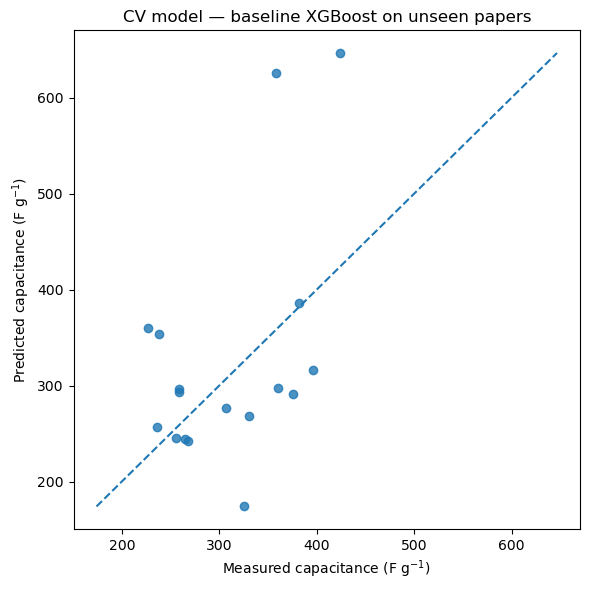

In [13]:
baseline_xgb = make_xgb_pipeline(cv_numeric_features, CATEGORICAL_FEATURES)
baseline_xgb.fit(X_train, y_train)
baseline_pred = baseline_xgb.predict(X_test)

xgb_baseline_metrics = regression_metrics(y_test, baseline_pred)

display(
    pd.DataFrame(
        [baseline_metrics, xgb_baseline_metrics],
        index=["Median baseline", "XGBoost baseline"],
    ).round(3)
)

parity_plot(y_test, baseline_pred, "CV model — baseline XGBoost on unseen papers")

### 6.3 Hyperparameter tuning on training papers only

The test papers remain untouched during tuning. `GroupKFold` is used inside the training set.

In [14]:
tuning_pipeline = make_xgb_pipeline(cv_numeric_features, CATEGORICAL_FEATURES)

param_distributions = {
    "model__n_estimators": [150, 250, 400, 600, 800],
    "model__learning_rate": [0.01, 0.02, 0.03, 0.05, 0.08],
    "model__max_depth": [2, 3, 4],
    "model__min_child_weight": [1, 2, 3, 5, 8],
    "model__subsample": [0.65, 0.8, 1.0],
    "model__colsample_bytree": [0.65, 0.8, 1.0],
    "model__reg_alpha": [0.0, 0.05, 0.1, 0.5, 1.0],
    "model__reg_lambda": [0.5, 1.0, 2.0, 5.0, 10.0],
}

inner_splits = min(N_SPLITS, groups_train.nunique())
inner_cv = GroupKFold(n_splits=inner_splits)

search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=N_SEARCH_ITER,
    scoring="neg_mean_absolute_error",
    cv=inner_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=0,
)

search.fit(X_train, y_train, groups=groups_train)

best_cv_model = search.best_estimator_

print("Best grouped-CV MAE on training papers:",
      round(-search.best_score_, 3), "F/g")
print("\nBest hyperparameters:")
for key, value in search.best_params_.items():
    print(f"  {key}: {value}")

Best grouped-CV MAE on training papers: 98.947 F/g

Best hyperparameters:
  model__subsample: 1.0
  model__reg_lambda: 1.0
  model__reg_alpha: 0.1
  model__n_estimators: 250
  model__min_child_weight: 8
  model__max_depth: 3
  model__learning_rate: 0.01
  model__colsample_bytree: 1.0


### 6.4 Final unseen-paper test

,MAE_F_g,RMSE_F_g,R2
Median baseline,71.496,92.637,-1.245
Untuned XGBoost,80.351,108.946,-2.105
Tuned XGBoost,65.429,82.962,-0.801


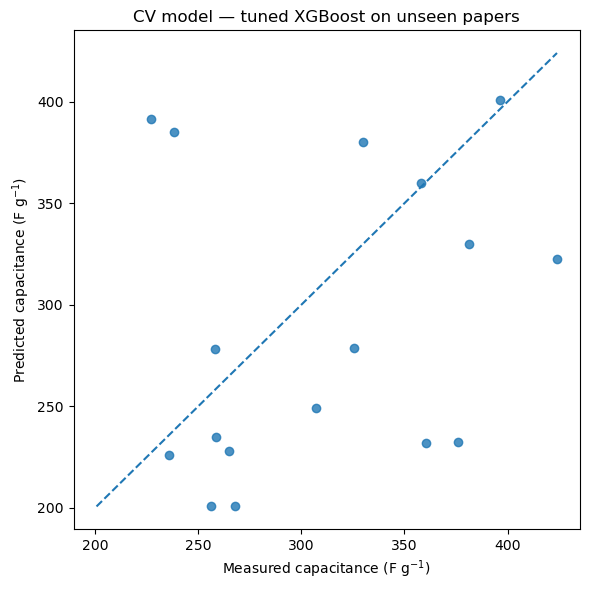

In [15]:
cv_test_pred = best_cv_model.predict(X_test)
cv_test_metrics = regression_metrics(y_test, cv_test_pred)

comparison = pd.DataFrame(
    [baseline_metrics, xgb_baseline_metrics, cv_test_metrics],
    index=["Median baseline", "Untuned XGBoost", "Tuned XGBoost"],
).round(3)

display(comparison)

parity_plot(y_test, cv_test_pred, "CV model — tuned XGBoost on unseen papers")

### 6.5 Grouped cross-validation of the selected configuration

Because the corpus is small, inspect both the **mean** and the **fold-to-fold spread**.

In [16]:
best_params_without_prefix = {
    key.replace("model__", ""): value
    for key, value in search.best_params_.items()
}

cv_selected_model = make_xgb_pipeline(
    cv_numeric_features,
    CATEGORICAL_FEATURES,
    **best_params_without_prefix,
)

cv_fold_metrics, cv_metric_summary = grouped_cv_summary(
    cv_selected_model,
    cv_data[cv_features],
    cv_data[TARGET],
    cv_data["paper_group"],
    n_splits=N_SPLITS,
)

display(cv_fold_metrics.round(3))
display(cv_metric_summary.round(3))

,fold,MAE_F_g,RMSE_F_g,R2
0,1,69.318,86.027,-0.145
1,2,156.772,321.013,-0.056
2,3,122.860,153.788,-0.820
3,4,51.900,69.852,0.109
4,5,61.274,84.624,0.017


,mean,std
MAE_F_g,92.425,45.314
RMSE_F_g,143.061,104.654
R2,-0.179,0.370


## 7. SHAP interpretation for the primary model

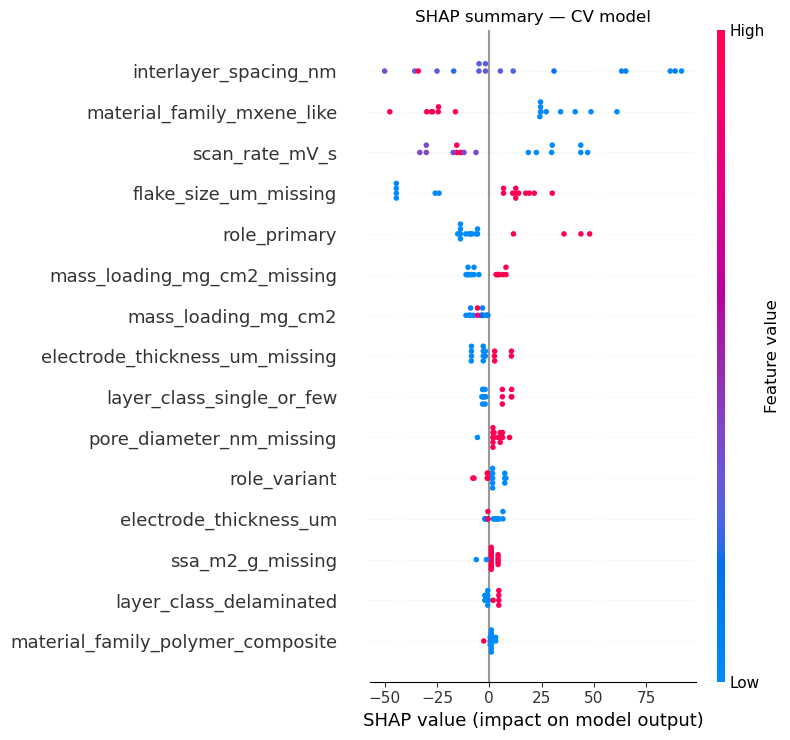

In [18]:
best_cv_model.fit(X_train, y_train)

preprocessor = best_cv_model.named_steps["preprocess"]
xgb_model = best_cv_model.named_steps["model"]

X_test_transformed = preprocessor.transform(X_test)
if sparse.issparse(X_test_transformed):
    X_test_dense = X_test_transformed.toarray()
else:
    X_test_dense = np.asarray(X_test_transformed)

# Numeric feature names
num_imputer = preprocessor.named_transformers_["num"].named_steps["imputer"]

num_feature_names = list(cv_numeric_features)

# Add names for missing-value indicator columns
if hasattr(num_imputer, "indicator_") and num_imputer.indicator_ is not None:
    indicator_names = [
        f"{cv_numeric_features[i]}_missing"
        for i in num_imputer.indicator_.features_
    ]
    num_feature_names += indicator_names


# Categorical feature names
onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]

if hasattr(onehot, "get_feature_names_out"):
    cat_feature_names = list(
        onehot.get_feature_names_out(CATEGORICAL_FEATURES)
    )
else:
    cat_feature_names = list(
        onehot.get_feature_names(CATEGORICAL_FEATURES)
    )


# Combine
feature_names = num_feature_names + cat_feature_names

X_test_shap = pd.DataFrame(
    X_test_dense,
    columns=feature_names,
    index=X_test.index,
)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_shap)

shap.summary_plot(
    shap_values,
    X_test_shap,
    max_display=15,
    show=False,
)
plt.title("SHAP summary — CV model")
plt.tight_layout()
plt.show()

In [19]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_SHAP": mean_abs_shap,
    })
    .sort_values("mean_abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

display(shap_importance.head(20))

,feature,mean_abs_SHAP
0,interlayer_spacing_nm,36.368664
1,material_family_mxene_like,31.245003
2,scan_rate_mV_s,24.869858
3,flake_size_um_missing,23.075510
4,role_primary,16.410320
5,mass_loading_mg_cm2_missing,7.458200
6,mass_loading_mg_cm2,5.238328
7,electrode_thickness_um_missing,4.860218
8,layer_class_single_or_few,4.721742
9,pore_diameter_nm_missing,3.975674


SHAP explains the fitted model; it does **not** establish causality. In a literature-derived dataset, descriptor availability, materials, processing, and reporting practices are correlated. Treat SHAP as hypothesis-generating structure–performance analysis.

## 8. Secondary model: GCD-conditioned capacitance

This subset is much smaller, so the model is intentionally simpler and is reported as **exploratory**.

In [20]:
gcd_features = gcd_numeric_features + CATEGORICAL_FEATURES

(
    Xg_train, Xg_test, yg_train, yg_test,
    gg_train, gg_test,
    gcd_train_rows, gcd_test_rows,
) = grouped_holdout(gcd_data, gcd_features)

print("GCD training observations:", len(Xg_train))
print("GCD test observations:", len(Xg_test))
print("GCD training papers:", gg_train.nunique())
print("GCD test papers:", gg_test.nunique())
print("Shared papers:", len(set(gg_train) & set(gg_test)))

GCD training observations: 22
GCD test observations: 13
GCD training papers: 12
GCD test papers: 4
Shared papers: 0


,MAE_F_g,RMSE_F_g,R2
Median baseline,75.731,120.249,-0.527
Exploratory XGBoost,53.508,102.602,-0.112


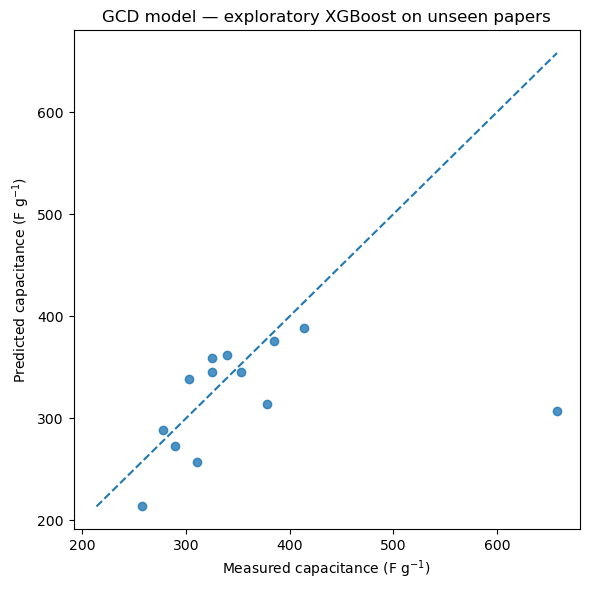

In [21]:
gcd_model = make_xgb_pipeline(
    gcd_numeric_features,
    CATEGORICAL_FEATURES,
    n_estimators=250,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
)

gcd_model.fit(Xg_train, yg_train)
gcd_pred = gcd_model.predict(Xg_test)

gcd_dummy = DummyRegressor(strategy="median")
gcd_dummy.fit(np.zeros((len(yg_train), 1)), yg_train)
gcd_dummy_pred = gcd_dummy.predict(np.zeros((len(yg_test), 1)))

gcd_comparison = pd.DataFrame(
    [
        regression_metrics(yg_test, gcd_dummy_pred),
        regression_metrics(yg_test, gcd_pred),
    ],
    index=["Median baseline", "Exploratory XGBoost"],
).round(3)

display(gcd_comparison)
parity_plot(yg_test, gcd_pred, "GCD model — exploratory XGBoost on unseen papers")

## 9. Export model-ready data and predictions

In [21]:
OUTPUT_DIR = DATA_PATH.parent

clean_csv_path = OUTPUT_DIR / "h2so4_model_ready.csv"
cv_predictions_path = OUTPUT_DIR / "cv_xgboost_holdout_predictions.csv"
cv_metrics_path = OUTPUT_DIR / "cv_xgboost_metrics.csv"
shap_path = OUTPUT_DIR / "cv_shap_importance.csv"

clean.to_csv(clean_csv_path, index=False)

prediction_table = cv_test_rows[
    ["source_file", "doi", "electrode_label", "paper_group", TARGET]
].copy()
prediction_table["predicted_capacitance_F_g"] = cv_test_pred
prediction_table["absolute_error_F_g"] = (
    prediction_table[TARGET] - prediction_table["predicted_capacitance_F_g"]
).abs()
prediction_table.to_csv(cv_predictions_path, index=False)

comparison.to_csv(cv_metrics_path)
shap_importance.to_csv(shap_path, index=False)

print("Saved:")
print(" -", clean_csv_path)
print(" -", cv_predictions_path)
print(" -", cv_metrics_path)
print(" -", shap_path)

Saved:
 - h2so4_model_ready.csv
 - cv_xgboost_holdout_predictions.csv
 - cv_xgboost_metrics.csv
 - cv_shap_importance.csv


## 10. What to report in a paper

At minimum, report:

- number of observations and unique papers;
- target/rate inclusion and exclusion rules;
- unit-normalization rules;
- descriptor missingness;
- paper-grouped train/test splitting;
- paper-grouped cross-validation;
- hyperparameter search space;
- MAE, RMSE, and R² with fold-to-fold variation;
- comparison with a naive baseline;
- SHAP results;
- the limitation that literature-derived observations are not independent controlled experiments.

### Recommended next improvement

Expand the corpus, especially for underreported geometry descriptors such as porosity, pore diameter, flake size, SSA, and mass loading. With the current sample size, **model interpretation is more defensible than claiming broad predictive generalization**.